In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['job_type_skills'] = df['job_type_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

In [2]:
df_da = df[df["job_title_short"] == "Data Analyst"].copy()


In [34]:
df_exploded = df_da.explode("job_skills")
skills_stats = df_exploded.groupby("job_skills").agg(
    median_salary=("salary_year_avg", "median"),
    job_count=("job_skills", "count")
)
skills_stats = skills_stats.sort_values(by="job_count", ascending=False).head(10)
skills_stats.head

<bound method NDFrame.head of             median_salary  job_count
job_skills                          
sql               92500.0      92428
excel             84479.0      66860
python            98500.0      57190
tableau           95000.0      46455
power bi          90000.0      39380
r                 92527.5      29996
sas               90000.0      27998
powerpoint        85000.0      13822
word              80000.0      13562
sap               90000.0      11280>

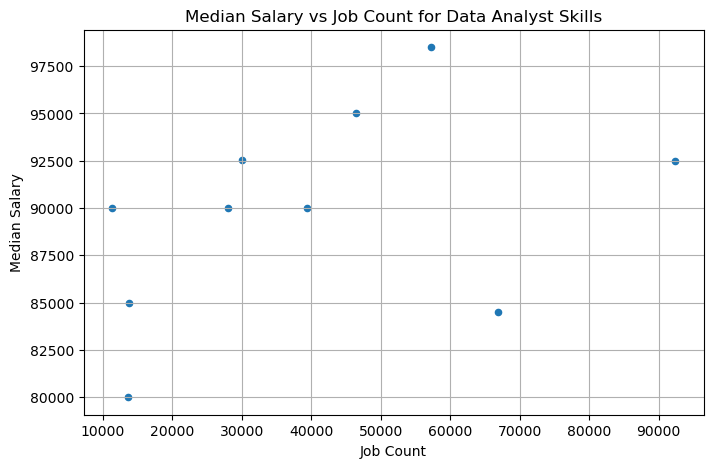

In [39]:
skills_stats.plot(kind='scatter', x='job_count', y='median_salary', figsize=(8, 5))
plt.title('Median Salary vs Job Count for Data Analyst Skills')
plt.xlabel('Job Count')
plt.ylabel('Median Salary')
plt.grid()
plt.show()

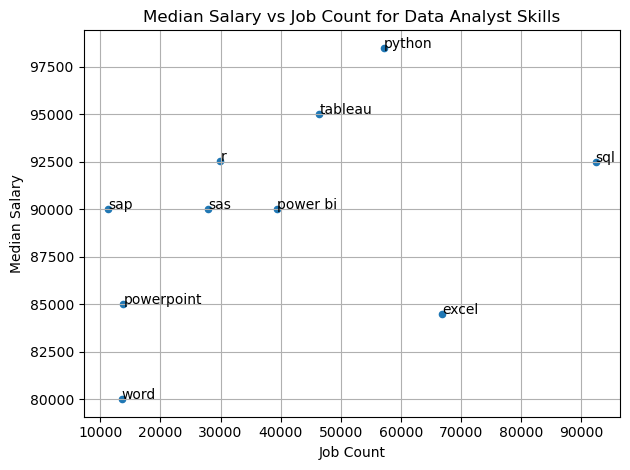

In [43]:
skills_stats.plot(kind='scatter', x='job_count', y='median_salary')

# plt.text() function to label the points
for i, text in enumerate(skills_stats.index):
    plt.text(skills_stats['job_count'].iloc[i], skills_stats['median_salary'].iloc[i], text)
    plt.title('Median Salary vs Job Count for Data Analyst Skills')
    plt.xlabel('Job Count')
    plt.ylabel('Median Salary')
plt.grid()   
plt.tight_layout()
plt.show()